# Práctica 4: Visualización







>[Práctica 4: Visualización](#scrollTo=K-a17PAajnE4)

>>[Fundamentos](#scrollTo=qawuRLBhZhfP)

>>[Crear un gráfico - Paso a paso](#scrollTo=vnEYI1U9RnNT)

>>>[Interfaz sencilla](#scrollTo=C_XtIwlTxa5Q)

>>>[Aplicación de estilos](#scrollTo=BFt_fSmLYi8Y)

>>>[Interfaz con Axes](#scrollTo=BzgKwYVFxdhv)

>>[Tipos de gráficos](#scrollTo=96KOr65PytIO)

>>>[Datos categóricos](#scrollTo=YFDGAWR0ZaB7)

>>>>[Gráfico de barras](#scrollTo=NrfzVH28ZaB7)

>>>[Datos numéricos](#scrollTo=BMasbOXIZaB-)

>>>>[Histograma](#scrollTo=0xXuAIxVZaB-)

>>>>[Boxplot](#scrollTo=Wj_vdDu_ZaB-)

>>>>[Violin Plot](#scrollTo=V09JzS1LZaB_)

>>>>[Strip Plot (gráfico de franjas)](#scrollTo=XAnIXE_0ZaB_)

>>>>[De puntos](#scrollTo=qD8G4JO0ZaB_)

>>>[Datos temporales](#scrollTo=RXVvLKWCZaCA)

>>>[Datos espaciales](#scrollTo=O_HCRMlrZaCA)

>>>>[Gráfico de dispersión (scatter plot)](#scrollTo=z1cSWwS4zAVC)

>>[Seaborn - visualizaciones útiles](#scrollTo=E_-HV_e6ykxb)

>>>[Boxplots comparativos](#scrollTo=MRH4XfaUzw0m)

>>>[Pairplot](#scrollTo=BYyfy8fHz7pd)

>>>[Bubble plot](#scrollTo=91AIR_YlevlL)

>>[Otro tipo de visualización de datos: Tablas](#scrollTo=8GHtyOcFLSfQ)

>>[Bibliografía](#scrollTo=LmlxWP8zeeV3)



## Fundamentos
* Es fundamental porque nos permite **explorar, entender y explicar** los datos.
* Está presente **desde el inicio** (Análisis Exploratorio de Datos) **hasta el final** (Comunicación de resultados) del proceso de la ciencia de datos.
* Aprender a visualizar los datos de manera eficiente es más que aprender a escribir código para generar gráficos, es aprender a pensar **qué información queremos mostrar y cuál es la mejor manera de hacerlo**. Es fundamental preguntarnos **a quiénes nos vamos a dirigir**.
* **Diferentes** tipos de gráficos **según el uso**: EDA, artículo académico, comunicación de resultados a usuarios externos, etc.


* Importancia de complementar los valores estadísticos con visualización:

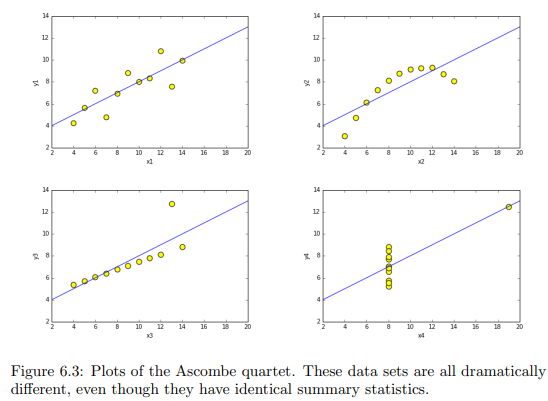

  *Fuente: Skiena, 2017*

  Los cuatro datasets tienen las mismas medias y varianzas en $x$ y en $y$, y la misma correlación entre variables. Es lo que mostrábamos la clase anterior con el ejemplo del  [datasaurus](https://www.research.autodesk.com/publications/same-stats-different-graphs/).

  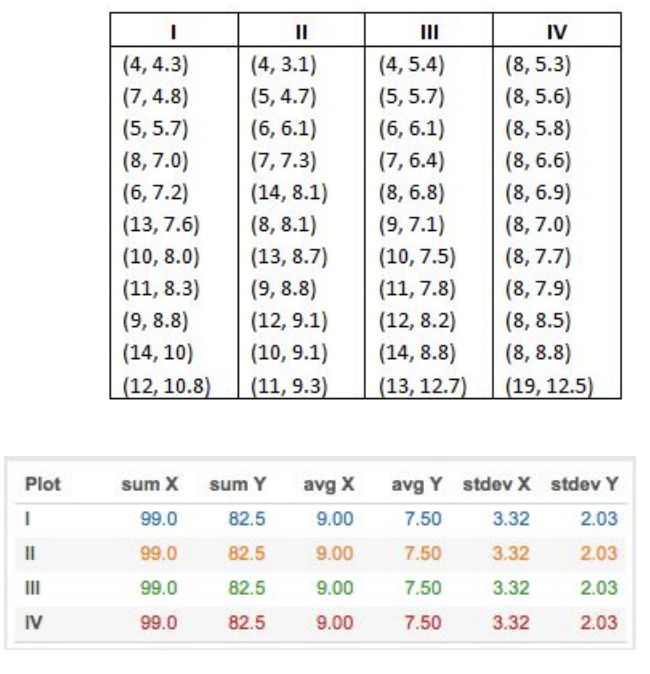

* Maximizar el **cociente datos/tinta**. Dejar que los datos hablen. El mejor gráfico es el que transmite el **mayor número de ideas en el menor tiempo posible**.

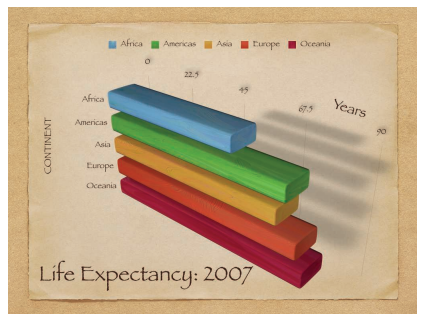


image.png

*Fuente: Healy, 2019*

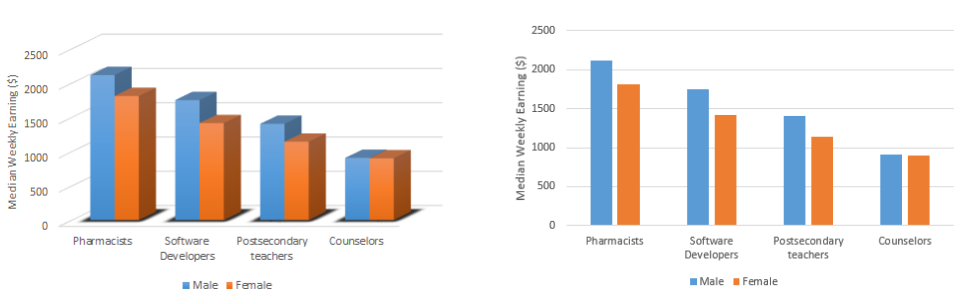

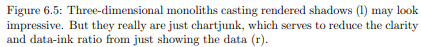

*Fuente: Skiena, 2017*

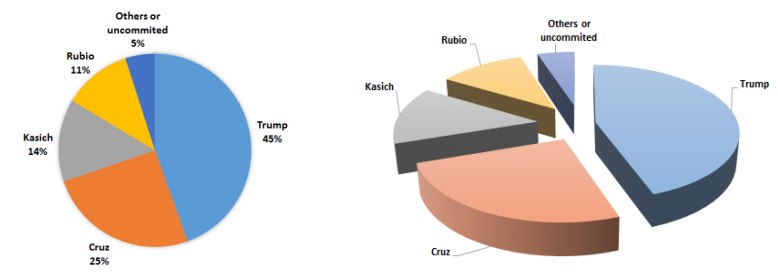

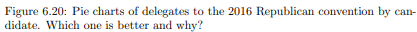

*Fuente: Skiena, 2017*

* Incluir nombre de los ejes, unidades de las variables, referencias.
* Utilizar tamaño de letra legible.
* En caso de estar en un informe, artículo o similar, incluir descripción al pie de la figura.
* Las figuras deben ser autoexplicativas.


* Uso efectivo del color: elegir colores que aporten a la interpretabilidad del gráfico. Ejemplo: datasets de vinos, se usó verde claro y violeta para vino blanco y tinto respectivamente.

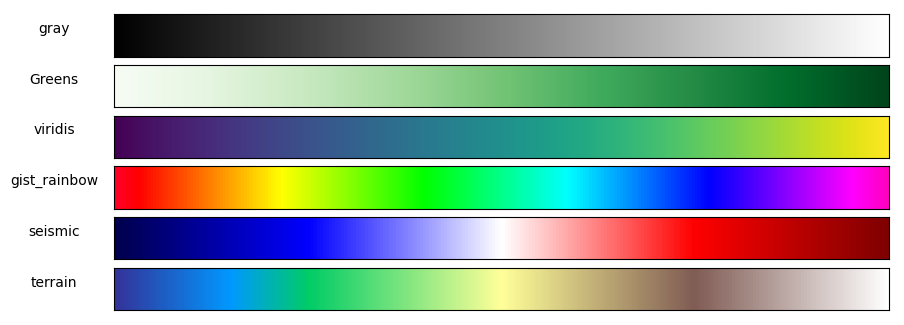

Paletas de colores:
- Secuenciales (para mostrar valores ordenados de menor a mayor)
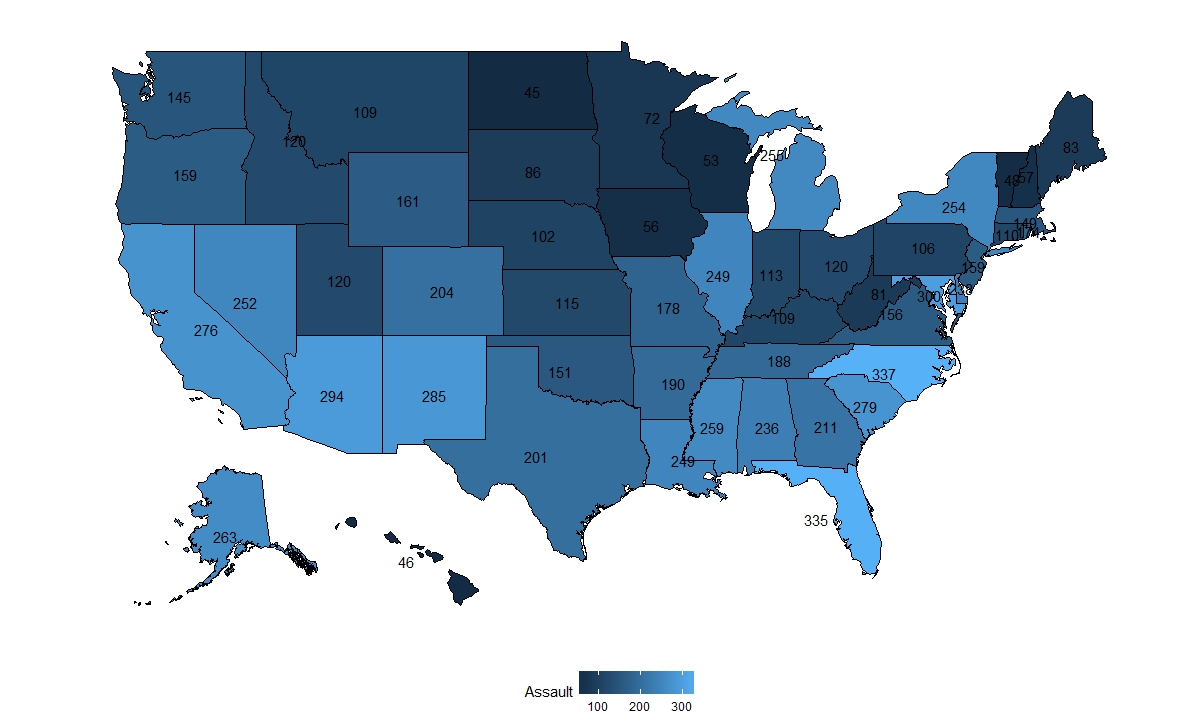
- Divergencia (para mostrar valores ordenados con algún valor crítico - por ej. el promedio o el 0)
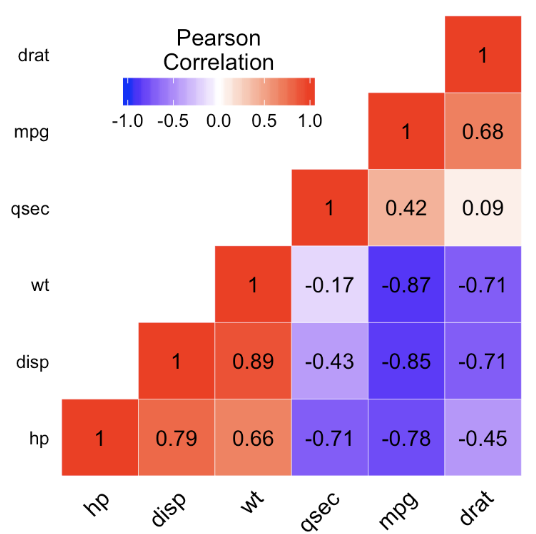
- Categoricas (para distinguir los distintos grupos)
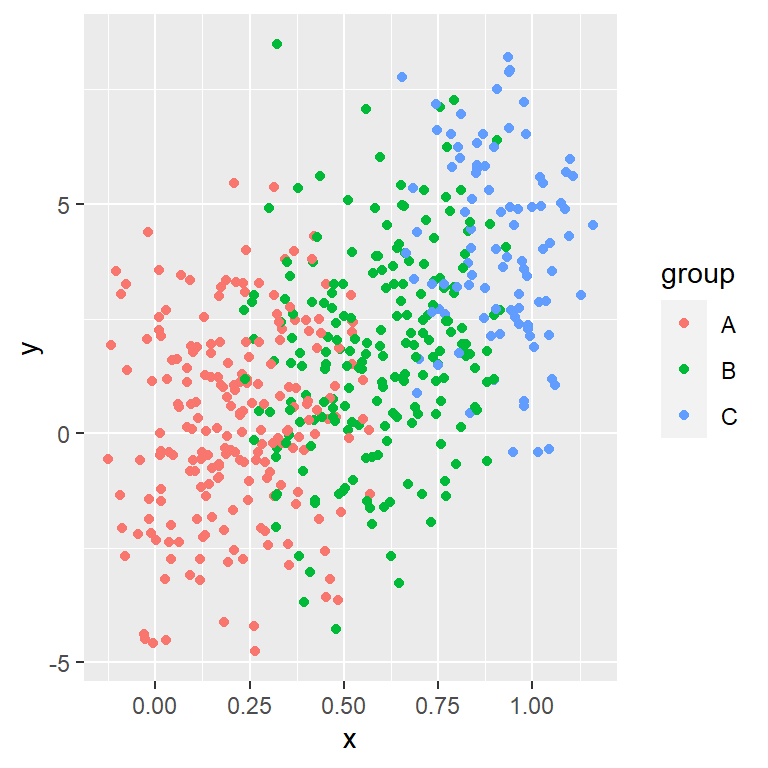

* Elegir escalas de colores que sean distinguibles para personas daltónicas.

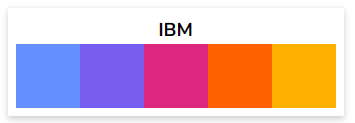

* En caso de saber que la impresión va a ser en blanco y negro, reemplazar los colores por estilos de línea o marcadores.

* No presentar las medias sin la varianza.
* No presentar interpolaciones o ajustes sin los datos reales.
* Seleccionar adecuadamente y dejar claramente expresada la escala.


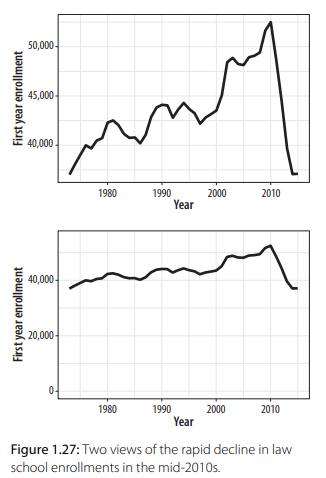

*Fuente: Healy, 2019*

* Gráficos comparativos: mantener la misma escala en todos los gráficos, o incluir todas las variables en un único gráfico. (Lo vemos más adelante con un ejemplo).

Algunos recursos con los que contamos para armar una visualización que aporte valor:

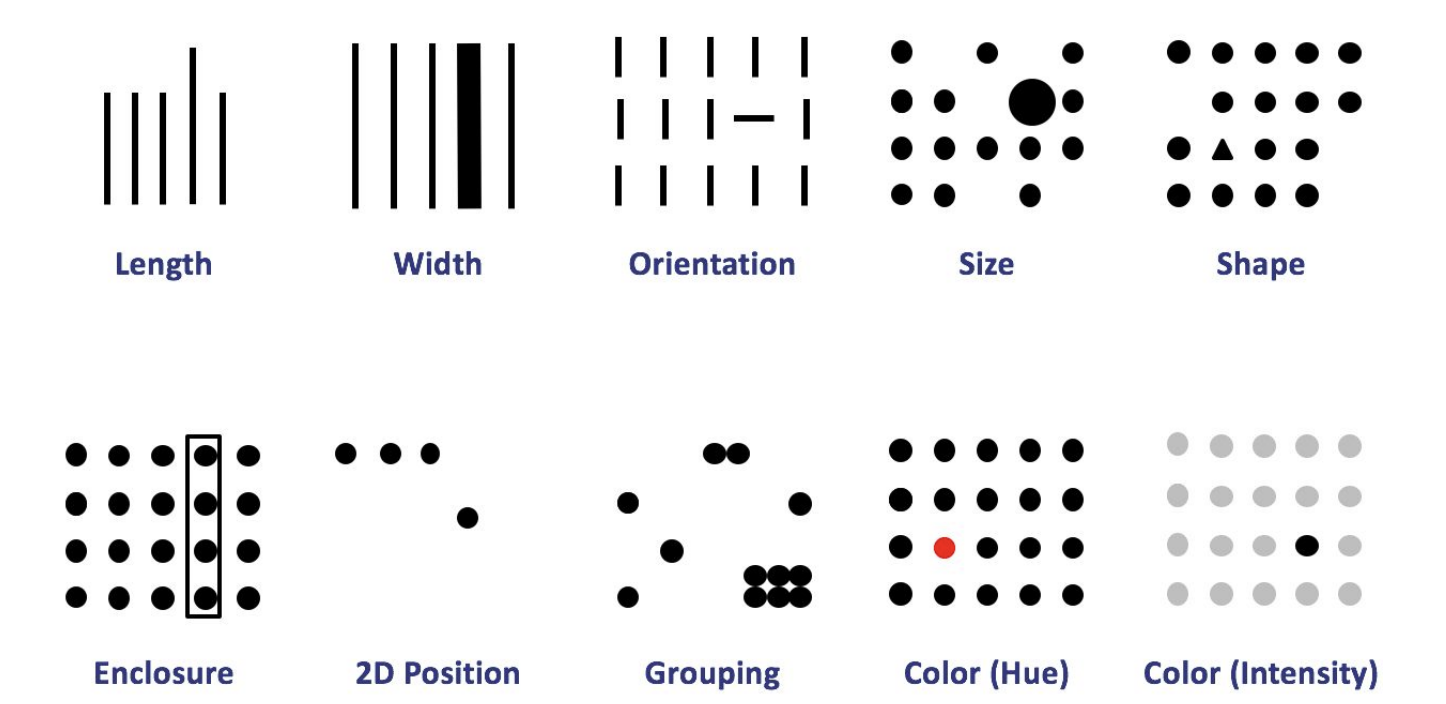

## Crear un gráfico - Paso a paso

Veremos dos maneras de hacer gráficos usando matplotlib, la librería estándar y más completa en ese sentido

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import matplotlib.dates as mdates
import seaborn as sns

### Interfaz sencilla

Iremos cargando a un gráfico de precio de cierre diario de acciones argentinas distintas herramientas que permitan mejorar la visualización.

Notar que siempre previo a una visualización es necesario entender que se requiere tener los tipos de dato limpios y transformarlos de la manera adecuada

In [ ]:
!gdown 1hZSZFL87JLxZdRkt-Pi5Rcc2h9507cYU

In [ ]:
stocks = pd.read_csv('ACCIONES.csv',sep=",",decimal = ',')
stocks['Fecha'] = pd.to_datetime(stocks['Fecha'],format="%d/%m/%Y")

In [ ]:
stocks

In [ ]:
stocks.info()

In [ ]:
print(stocks.head(1))
print(stocks.tail(1))

In [ ]:
plt.plot('Fecha','TGS',data = stocks)

A este gráfico le faltan varias cosas...



1. Título `plt.title()`
2. Etiquetas `plt.label()`
3. Leyendas `plt.legend()`
4. Colores y marcadores y estilos



In [ ]:
#Plot de los 3 ADR
plt.plot('Fecha','TGS',data = stocks, label = 'TGS', color = '#FF1900')
plt.plot('Fecha','YPF',data=stocks,label = 'YPF', color = '#230AFF')
plt.plot('Fecha','PAM',data = stocks, label = 'PAM', color = '#0A89FF')
plt.plot('Fecha','VIST',data = stocks, label = 'VIST', color = '#BF3097')

#Sumo parámetros adicionales al gráfico
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.title('Acciones argentinas desde agosto de 2023 hasta abril de 2024')
plt.legend()
plt.tight_layout()

fig = plt.gcf()
fig.savefig('figura1.png')

plt.show()


Esta forma de graficar es sencilla. Hay un trabajo implícito de la librería de tomar una configuración ya previa y tocar en menor medida.

https://matplotlib.org/stable/users/explain/figure/api_interfaces.html#api-interfaces

El trade-off es la limitación que uno pueda tener con el gráfico, por lo que veremos de llegar al mismo resultado utilizando una interfaz orientada a cada tipo de objeto.

### Aplicación de estilos

matplotlib cuenta con muchos estilos predefinidos que ajustan muchos parámetros a la vez, sin la necesidad de que tengamos que poder visualizar uno a uno. Se sugiere ir probandolos y definir uno previo a preparar las visualizaciones o bien tomar uno y alterarlo.

In [ ]:
plt.style.available

In [ ]:
#plt.style.use('ggplot')

In [ ]:
# No está en la lista... pero con esto vuelven al default
plt.style.use('default')

### Interfaz con `Axes`

Al trabajar de la siguiente manera lo que uno termina haciendo es una especie de cuadro en blanco donde uno primero fija la cantidad de plots que va a mostrar.

El "lienzo" está representado por la `Figure` y cada plot por los `Axes`.

Definido y delimitado el lienzo, se puede acceder a cada `Axes` particular y editarlo de forma indivual de acuerdo a lo que necesitemos.


In [ ]:
fig = plt.figure()
fig.show()

In [ ]:
#Ejemplo con un único plot
fig = plt.figure()
ax = fig.subplots()
ax.plot('Fecha','TGS',data = stocks, label = 'TGS', color = '#FF1900')
ax.plot('Fecha','YPF',data=stocks,label = 'YPF', color = '#230AFF')
ax.plot('Fecha','PAM',data = stocks, label = 'PAM', color = '#0A89FF')
ax.plot('Fecha','VIST',data = stocks, label = 'VIST', color = '#BF3097')

Vamos a graficar todo en distintos subplots

https://matplotlib.org/stable/users/explain/axes/axes_intro.html


In [ ]:
# Con la siguiente línea de inicio creamos el canvas
# que tendrá 4 espacios donde graficaremos (2x2)

fig, axs = plt.subplots(2, 2, figsize= (12,8))



In [ ]:
axs[0,0].plot('Fecha','TGS',data = stocks, label = 'TGS', color = '#FF1900')
axs[0,1].plot('Fecha','YPF',data=stocks,label = 'YPF', color = '#230AFF')
axs[1,0].plot('Fecha','PAM',data = stocks, label = 'PAM', color = '#0A89FF')
axs[1,1].plot('Fecha','VIST',data = stocks, label = 'VIST', color = '#BF3097')

fig.suptitle('Acciones Energía Argentinas')
fig

Vamos a hacer los siguientes cambios:
- Formatear los xticks de los ejes con fechas porque no se ven
- Dejar dos escalas en Y para cada tipo de acción
- Sumar titulos individuales a los gráficos indicando la empresa.
- Sumar el volumen operado en el caso de TGS

In [ ]:
for i,ax in enumerate(axs.flat):
  print(i)
  print(ax)

In [ ]:
#Escalas en Y
axs[0, 0].set_ylim(8, 22)
axs[0, 1].set_ylim(8, 22)
axs[1, 0].set_ylim(22, 60)
axs[1, 1].set_ylim(22, 60)  #Limites en USD para los ejes en Y

acciones = ['Transportadora Gas del Sur','YPF','Pampa Energía','Vista Oil & Gas']

# Edito el formato del eje X
for i, ax in enumerate(axs.flat):
    if i in [2,3]:
      ax.xaxis.set_major_locator(mdates.MonthLocator())
      ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
      ax.tick_params(axis='x', rotation=45)  # Roto los labels 45°
    else:
      ax.set_xticklabels([])  # Asigno lista vacía de labels
    #Coloco labels
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Precio en USD')
    ax.set_title(f'{acciones[i]}')
    ax.grid(True)

#Titulo del gráfico
fig.suptitle('PANEL OIL & GAS')


plt.tight_layout()  # Se recomienda usar esto asi se encarga de dar el padding correcto.
# No siempre funciona

fig

Sumemosle contexto al gráfico con anotaciones o lineas verticales u horizontales indicando mínimos y máximos


In [ ]:
stocks['Fecha'].sample(2)

In [ ]:
stocks[['TGS','YPF','PAM','VIST']].min()

In [ ]:
# Le podemos sumar contexto con las fechas de primera vuelta
# y segunda vuelta de las elecciones

# Convertimos a objetos datetime las elecciones, ya que es el formato del eje x
primarias = datetime.datetime.strptime('2023-10-22', '%Y-%m-%d')
balotaje = datetime.datetime.strptime('2023-11-19', '%Y-%m-%d')

minimos = stocks[['TGS','YPF','PAM','VIST']].min()
maximos = stocks[['TGS','YPF','PAM','VIST']].max()

for i, ax in enumerate(axs.flat):
  minimo = minimos[i]
  maximo = maximos[i]
  #Ploteo las lineas que interesan
  ax.axvline(x=primarias,color='gray', linestyle='dashed')
  ax.axvline(x=balotaje,color='black', linestyle='dashed')
  ax.axhline(y = minimo, color = 'red', alpha = 0.4)
  ax.axhline(y = maximo, color = 'green', alpha = 0.4)

# Agregamos anotaciones de las primarias y balotaje
  ax.text(primarias-datetime.timedelta(days =5), ax.get_ylim()[1]*0.8, 'PRIMARIAS', color='black', ha='center', va='bottom', rotation = 90)
  ax.text(balotaje-datetime.timedelta(days =5), ax.get_ylim()[1]*0.8, 'BALOTAJE', color='black', ha='center', va='bottom',rotation= 90)


fig

In [ ]:
print(minimos)
print(maximos)

Modificaciones al gráfico existente

In [ ]:
# Sumamos el volumen operado por TGS (posicion (0,0))

# Creo un eje secundario en el elemento (0,0) solamente
ax_volumen = axs[0, 0].twinx()

# Hago un gráfico de barras
ax_volumen.bar(stocks['Fecha'], stocks['VOLUMEN_TGS'], color='orange', alpha=0.4, label='Volumen')

# Le agrego la leyenda
ax_volumen.legend(loc='upper right')


plt.tight_layout()

In [ ]:
fig

Un poco de edición de variables...

Pandas tiene una media movil incorporada. Vamos a sumarle 4 columnas a los gráficos y graficarla en punteado, y setear para cada plot los margenes laterales sin datos para que no parezca que la serie se interrumpa

In [ ]:
#Agreguemos las medias móviles al dataframe existente

stocks['MM_14_TGS'] = stocks.rolling(14, min_periods=1)['TGS'].mean()
stocks['MM_14_YPF'] = stocks.rolling(14, min_periods=1)['YPF'].mean()
stocks['MM_14_PAM'] = stocks.rolling(14, min_periods=1)['PAM'].mean()
stocks['MM_14_VIST'] = stocks.rolling(14, min_periods=1)['VIST'].mean()

medias = stocks[['Fecha','MM_14_TGS','MM_14_YPF','MM_14_PAM','MM_14_VIST']]

In [ ]:
medias

In [ ]:
# Sumemos a cada ax los ploteos de medias móviles

axs[0,0].plot('Fecha','MM_14_TGS',data=medias,linestyle='dotted',color='black',label='Media móvil 14 días')
axs[0,1].plot('Fecha','MM_14_YPF',data=medias,linestyle='dotted',color='black',label='Media móvil 14 días')
axs[1,0].plot('Fecha','MM_14_PAM',data=medias,linestyle='dotted',color='black',label='Media móvil 14 días')
axs[1,1].plot('Fecha','MM_14_VIST',data=medias,linestyle='dotted',color='black',label='Media móvil 14 días')

for ax in axs.flat:
  ax.set(xlim=(min(stocks['Fecha']), max(stocks['Fecha'])))

In [ ]:
fig

**Exportar la figura**:


In [ ]:
#Importante los dpi
fig.savefig('figura2.png', dpi= 300)

## Tipos de gráficos

### Datos categóricos

Para datos categóricos, sean variables ordinales o categóricas podemos representarlos utilizando gráficos como

- De barras: para comparar cantidades
- Barras agrupadas (stackeado o no): comparar proporciones dentro de una categoría
- De torta ([Save the pies for dessert](https://www.perceptualedge.com/articles/visual_business_intelligence/save_the_pies_for_dessert.pdf))

#### Gráfico de barras

Objetivo: presentar cantidades proporcionales a los valores que representan. En un eje van las categorías y en el otro la variable a ser cuantificada. Si queremos mostrar más de una categoría, hablamos de un gráfico de barras apilado o stackeado.

In [2]:
# Descarga de celulares que salieron a la venta en 2025
!gdown 1dd_EuqeqwFsIyPnfITLU_puM0FPBLDUF

Downloading...
From: https://drive.google.com/uc?id=1dd_EuqeqwFsIyPnfITLU_puM0FPBLDUF
To: /content/Mobiles Dataset (2025).csv
100% 140k/140k [00:00<00:00, 4.22MB/s]


In [3]:
df_celulares = pd.read_csv('Mobiles Dataset (2025).csv', encoding='latin1')

df_celulares

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,Poco,Pad 5G 128GB,571g,8GB,8MP,8MP,Snapdragon 7s Gen 2,"10,000mAh",12.1 inches,"PKR 66,220","INR 23,999","CNY 2,099",USD 280,"AED 1,029",2024
926,Poco,Pad 5G 256GB,571g,8GB,8MP,8MP,Snapdragon 7s Gen 2,"10,000mAh",12.1 inches,"PKR 71,220","INR 25,999","CNY 2,299",USD 300,"AED 1,099",2024
927,Samsung,Galaxy Z Fold6 256GB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,"PKR 604,999","INR 164,999","¥13,999","USD 1,899","AED 7,199",2024
928,Samsung,Galaxy Z Fold6 512GB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,"PKR 544,999","INR 176,999","CNY 15,999",USD 1719,"AED 7,699",2024


<BarContainer object of 19 artists>

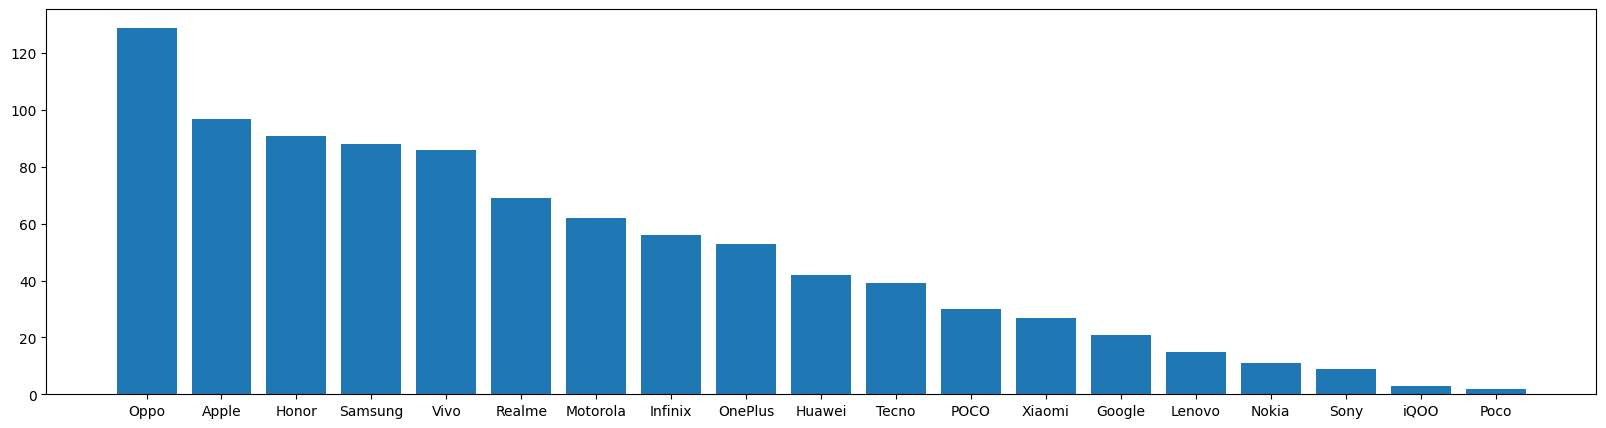

In [4]:
# Creo la figura y el axis
fig, ax = plt.subplots(figsize=(20,5))

# Vamos a plotear cantidad de modelos por marca
modelos = df_celulares['Company Name'].value_counts()

# Importante, esto es una serie. Nuestro x se vuelven los indices y los "y" la serie en sí

ax.bar(modelos.index, modelos.values)


Retoquemos el gráfico
- Textos, etiquetas, colores
- Un grid
- Curva acumulada (Pareto)



In [9]:
# Textos del gráfico
ax.set_title('Cantidad de modelos de celular lanzados en 2025', fontsize=16)
ax.set_xlabel('Marca', fontsize=14)
ax.set_ylabel('Cantidad de modelos', fontsize=14)

# Ticks (nombres de categorias)
ax.tick_params(axis='both', labelsize=12)

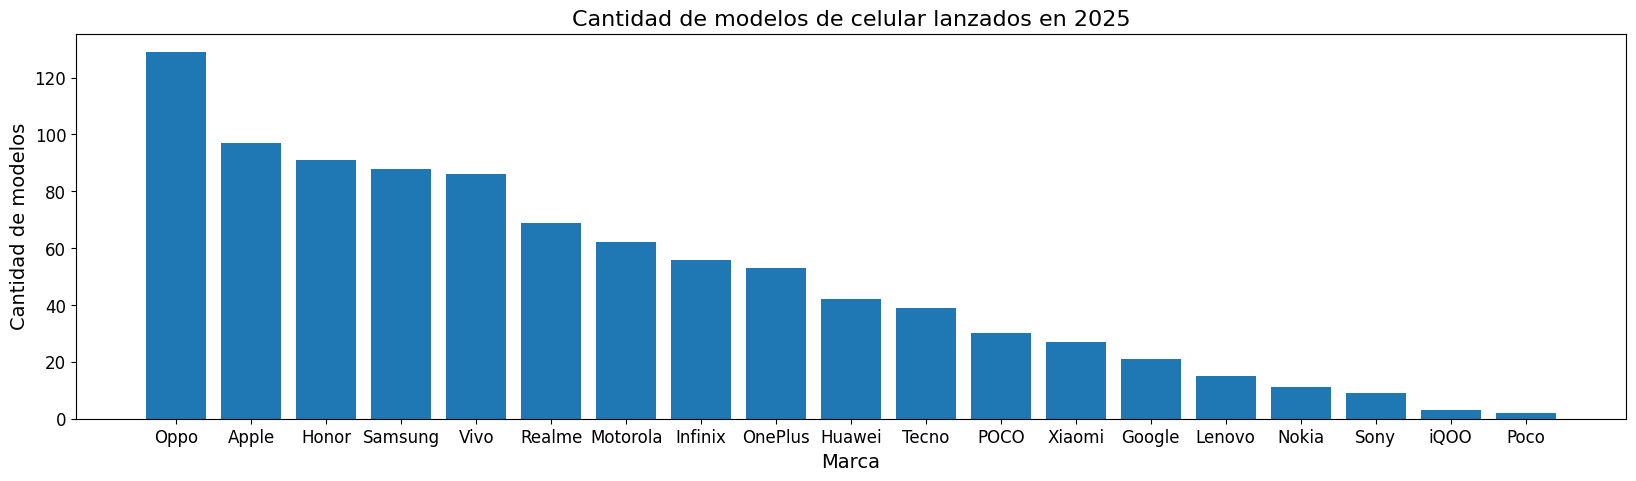

In [10]:
fig

In [11]:
# Colores del gráfico y grid cada 20 modelos
ax.bar(modelos.index, modelos.values, color='skyblue', edgecolor='black')
ax.grid(True, axis = 'y', linestyle = '--' , alpha = .7)

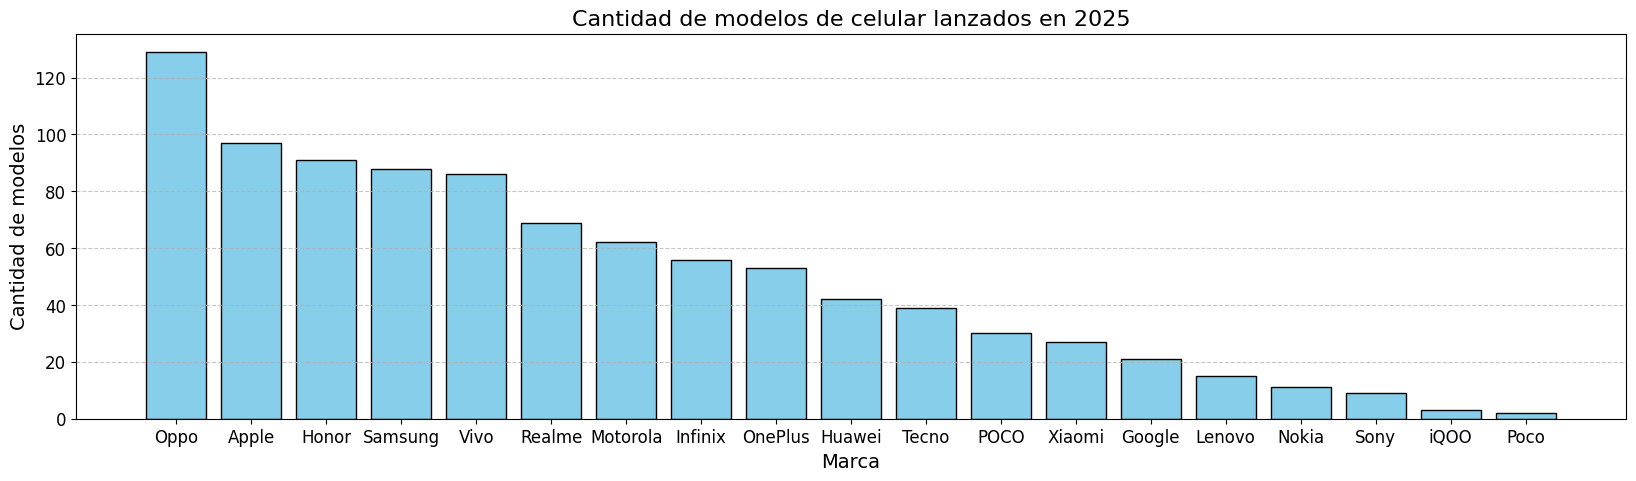

In [12]:
fig

In [13]:
# Cambiemos límites del gráfico y agreguemos cantidad de
# modelos de los celulares con más modelos disponibles

ax.set_ylim(0,150)
for i, value in enumerate(modelos.values):
    ax.text(i, value + 1, str(value), ha='center', va='bottom', fontsize=12)
    if i == 4:
        break
fig

# Para el pareto le tenemos que agregar un gráfico secundario y calcular previamente porcentajes respecto del total
porcentaje = modelos.values.cumsum() / modelos.values.sum() * 100

#Creamos una nueva instancia de Axes dentro del gráfico
ax2 = ax.twinx()
ax2.plot(modelos.index, porcentaje, color='red', marker='o', linestyle='-')
ax2.set_ylabel('Porcentaje acumulado (%)',fontsize =12)
ax2.set_ylim(0, 110)
ax2.axhline(80, color = 'red',linestyle = 'dashed', linewidth = 2)

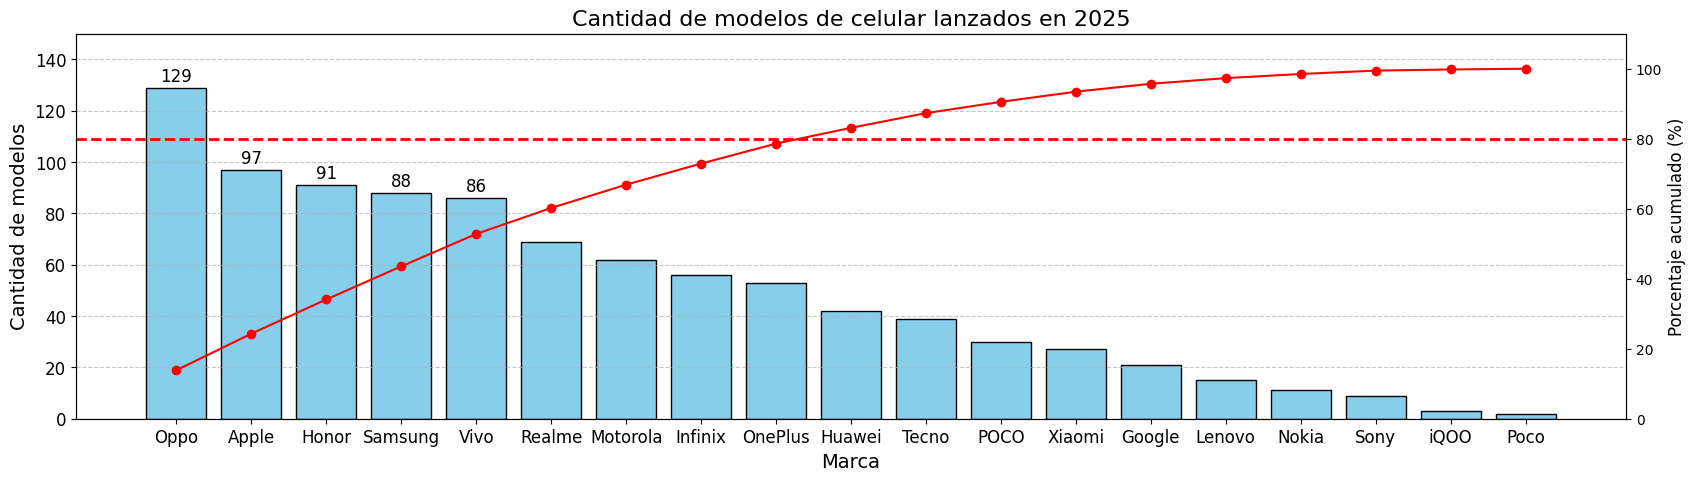

In [14]:
fig

Para barras stackeadas nos fijaremos en celulares Samsung, Moto y OnePLus y sus cámaras traseras

In [17]:
df_celulares['Back Camera'].value_counts()

,count
Back Camera,
50MP,182
13MP,76
48MP,60
64MP,57
50MP + 2MP,39
...,...
50MP (wide) + 40MP (ultrawide) + 48MP (telephoto),1
48MP (wide) + 40MP (ultrawide) + 48MP (telephoto),1
50MP (wide) + 13MP (ultrawide) + 12MP (periscope telephoto),1


In [19]:
df_camaras = df_celulares[df_celulares['Company Name'].isin(['Samsung','Motorola','OnePlus'])]
df_camaras['Back Camera'].value_counts()

,count
Back Camera,
50MP,48
50MP + 12MP,18
50MP + 8MP,15
13MP,12
50MP + 2MP,9
108MP + 12MP,8
16MP,6
64MP,6
50MP + 48MP,6


In [20]:
df_camaras = df_camaras[df_camaras['Back Camera'].isin(['50MP','50MP + 12MP','50MP + 8MP','13MP','108MP + 12MP'])]

In [21]:
df_camaras_agrupado = df_camaras.groupby(['Company Name','Back Camera'])['Company Name'].count()

In [22]:
df_camaras_agrupado

Company Name  Back Camera 
Motorola      13MP             4
              50MP            43
OnePlus       13MP             2
              50MP             1
              50MP + 8MP      11
Samsung       108MP + 12MP     8
              13MP             6
              50MP             4
              50MP + 12MP     18
              50MP + 8MP       4
Name: Company Name, dtype: int64

In [23]:
# Hacemos unstack para poder plotear
df_camaras = df_camaras_agrupado.unstack(fill_value=0)
df_camaras

Back Camera,108MP + 12MP,13MP,50MP,50MP + 12MP,50MP + 8MP
Company Name,,,,,
Motorola,0,4,43,0,0
OnePlus,0,2,1,0,11
Samsung,8,6,4,18,4


In [25]:
for idx, column in enumerate(df_camaras.columns):
  print(idx, column)

0 108MP + 12MP
1 13MP
2 50MP
3 50MP + 12MP
4 50MP + 8MP


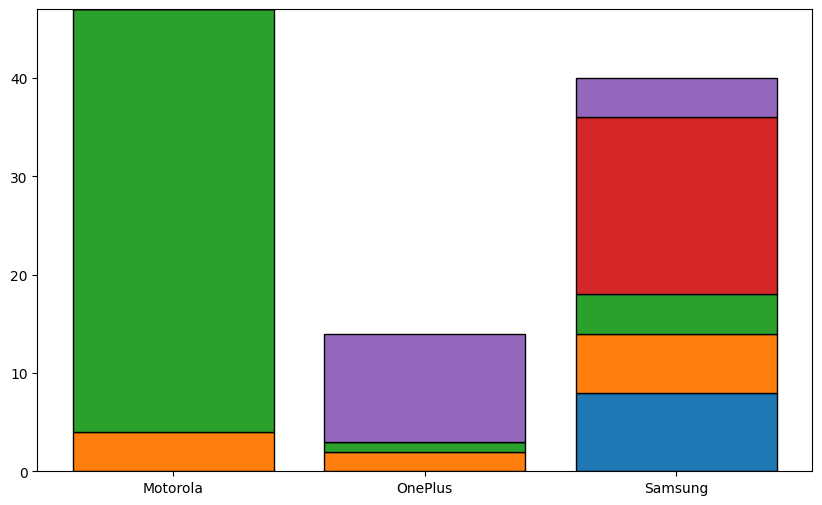

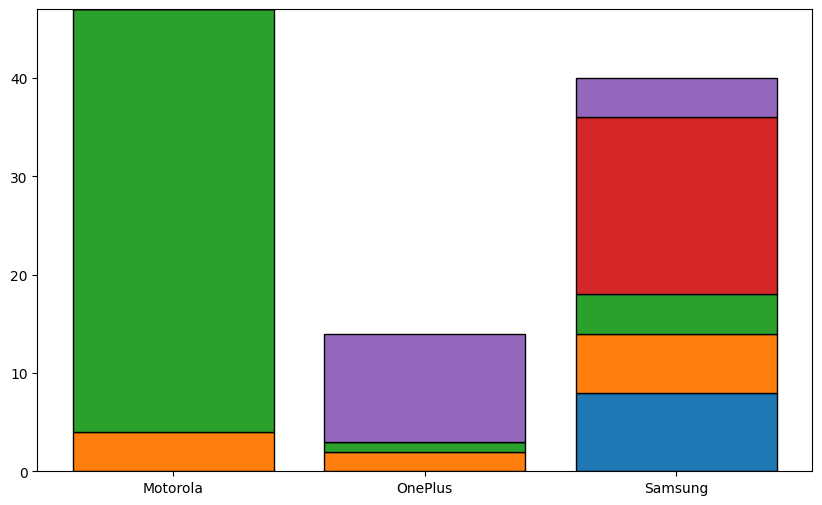

In [24]:
#Figura instanciada
fig, ax = plt.subplots(figsize = (10,6))

# Altura base de barras
bottom = [0] * len(df_camaras)

# Itero por cámaras
for idx, column in enumerate(df_camaras.columns):
    ax.bar(
        df_camaras.index,
        df_camaras[column],
        bottom=bottom,
        label=column,
        edgecolor='black'
    )
    # Actualizo el pie del siguiente barra
    bottom = [i + j for i, j in zip(bottom, df_camaras[column])]

fig

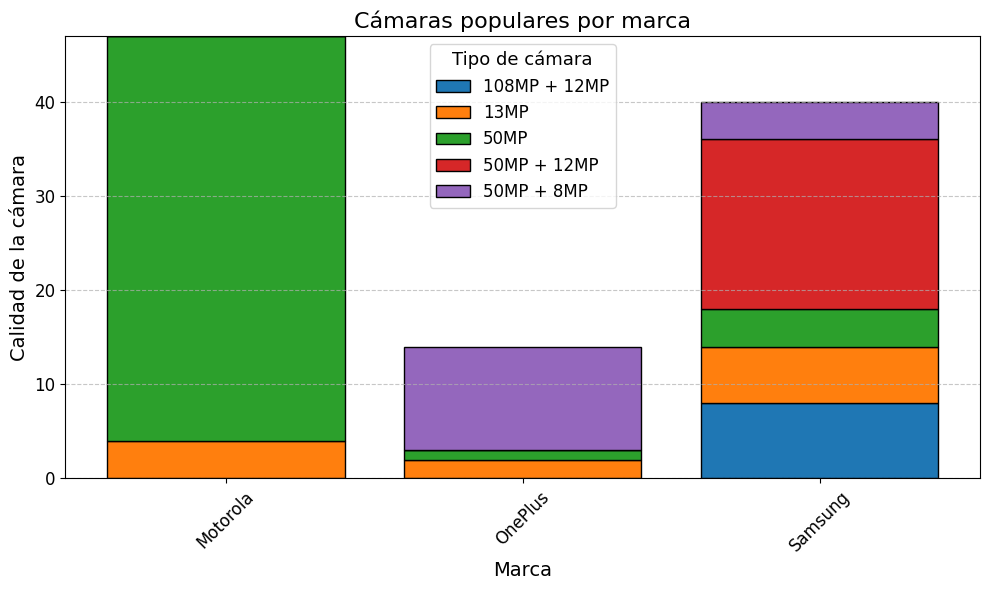

In [26]:
ax.set_title('Cámaras populares por marca', fontsize=16)
ax.set_xlabel('Marca', fontsize=14)
ax.set_ylabel('Calidad de la cámara', fontsize=14)
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.legend(title='Tipo de cámara', fontsize=12, title_fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()
fig

Sumamente complejo en este tipo de gráfico. Si usamos seaborn?

In [27]:
import seaborn as sns
sns.set_style("whitegrid")

In [28]:
df_camaras.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, Motorola to Samsung
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   108MP + 12MP  3 non-null      int64
 1   13MP          3 non-null      int64
 2   50MP          3 non-null      int64
 3   50MP + 12MP   3 non-null      int64
 4   50MP + 8MP    3 non-null      int64
dtypes: int64(5)
memory usage: 144.0+ bytes


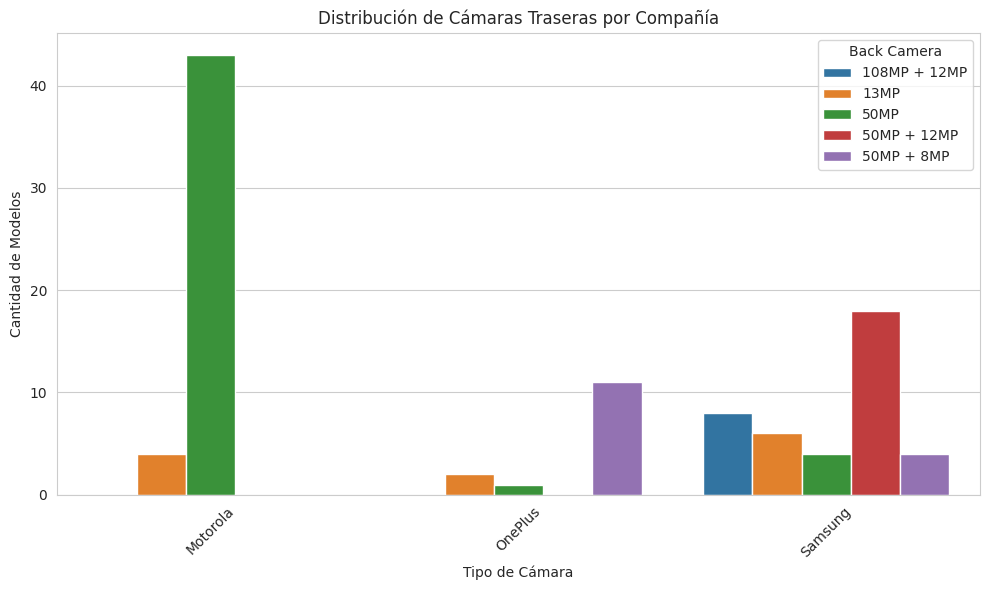

In [31]:
# Resetear índice y convertir a formato largo
df_camaras.index.name = "Marca"  # Darle nombre al índice
df_long = df_camaras.reset_index().melt(id_vars="Marca", var_name="Back Camera", value_name="Count")
df_long.rename(columns={"index": "Marca"}, inplace=True)

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=df_long, x="Marca", y="Count", hue="Back Camera")

plt.title("Distribución de Cámaras Traseras por Compañía")
plt.xlabel("Tipo de Cámara")
plt.ylabel("Cantidad de Modelos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Datos numéricos

Para el caso de datos numéricos, sean variables continuas o discretas, podemos listar los siguientes gráficos que resultarán relevantes a lo largo de la materia:

- Histograma
- Boxplot
- Violin
- Strip plot
- De puntos (Cleveland Dot Plots)

In [32]:
# Descarga de iris
!gdown 1iBREApJVlug6hqsxaYlTDshnNqP-B0ds

Downloading...
From: https://drive.google.com/uc?id=1iBREApJVlug6hqsxaYlTDshnNqP-B0ds
To: /content/iris.csv
100% 5.11k/5.11k [00:00<00:00, 17.6MB/s]


In [33]:
iris = pd.read_csv('iris.csv')

In [34]:
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


#### Histograma

Veamos la distribución de una variable del dataset de flores (largo del pétalo)

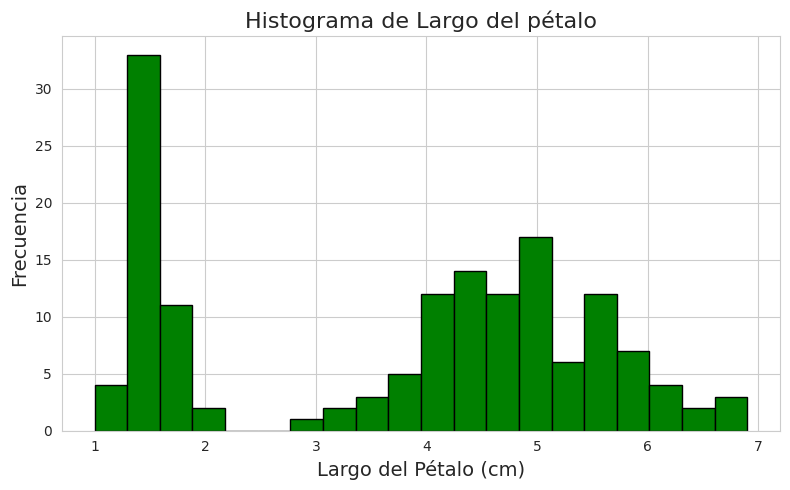

In [35]:
#Figura
fig, ax = plt.subplots(figsize=(8, 5))
# Histograma. Se definen bins, color
ax.hist(iris['PetalLengthCm'], bins=20, color='green', edgecolor='black')
ax.set_title('Histograma de Largo del pétalo', fontsize=16)
ax.set_xlabel('Largo del Pétalo (cm)', fontsize=14)
ax.set_ylabel('Frecuencia', fontsize=14)
fig.tight_layout() # Para no pisar etiquetas
plt.show()


#### Boxplot

Veamos lo mismo viendo la mediana, cuartiles y outliers en la distribución

/tmp/ipython-input-3063554891.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=species)


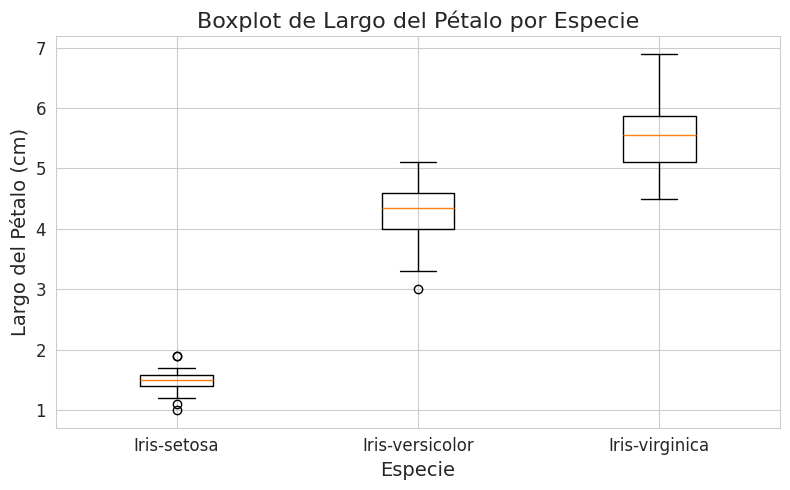

In [36]:
# Matplotlib precisa definir la data. Con seaborn no es necesario
species = iris['Species'].unique()
data_to_plot = [iris.loc[iris['Species'] == sp, 'PetalLengthCm'] for sp in species]

# Crear el gráfico
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data_to_plot, labels=species)

# Personalizar
ax.set_title('Boxplot de Largo del Pétalo por Especie', fontsize=16)
ax.set_xlabel('Especie', fontsize=14)
ax.set_ylabel('Largo del Pétalo (cm)', fontsize=14)
ax.tick_params(labelsize=12)

fig.tight_layout()
plt.show()


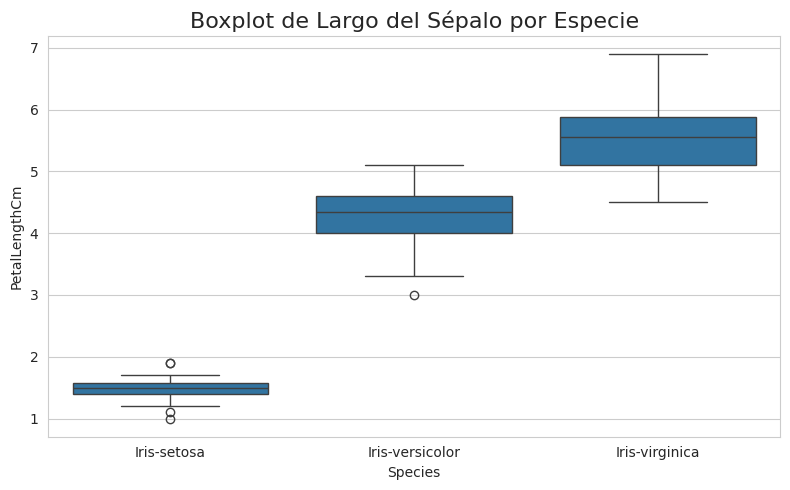

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=iris, x='Species', y='PetalLengthCm', ax=ax)
ax.set_title('Boxplot de Largo del Sépalo por Especie', fontsize=16)
fig.tight_layout()
plt.show()

#### Violin Plot

Le sumamos la densidad al histograma

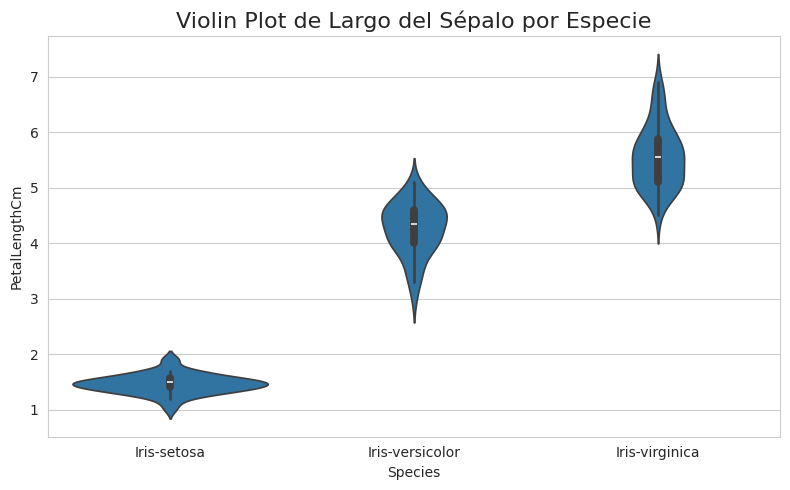

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=iris, x='Species', y='PetalLengthCm', ax=ax)
ax.set_title('Violin Plot de Largo del Sépalo por Especie', fontsize=16)
fig.tight_layout()
plt.show()

#Con matplotlib implica que creemos la función densidad antes, plotearla en vertical, etc...

#### Strip Plot (gráfico de franjas)

Para ver las observaciones indivuales

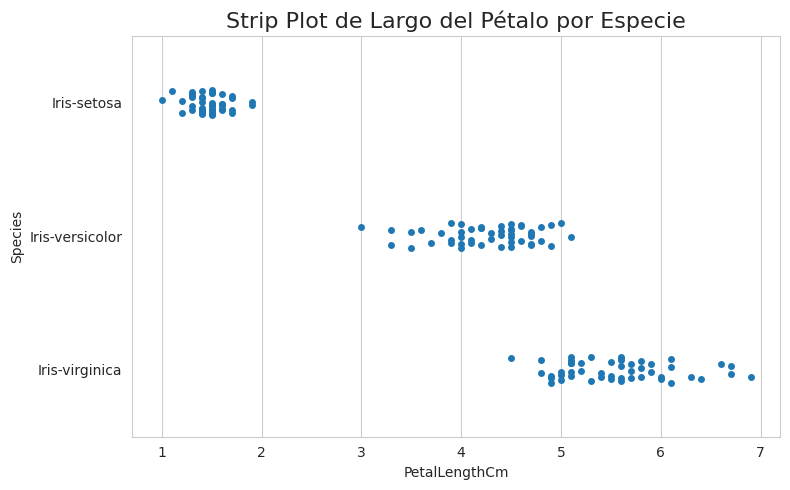

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.stripplot(data=iris, x='PetalLengthCm',y='Species', ax=ax, jitter=True) # Ajustar jitter
ax.set_title('Strip Plot de Largo del Pétalo por Especie', fontsize=16)
fig.tight_layout()
plt.show()


<Axes: xlabel='PetalLengthCm', ylabel='Species'>

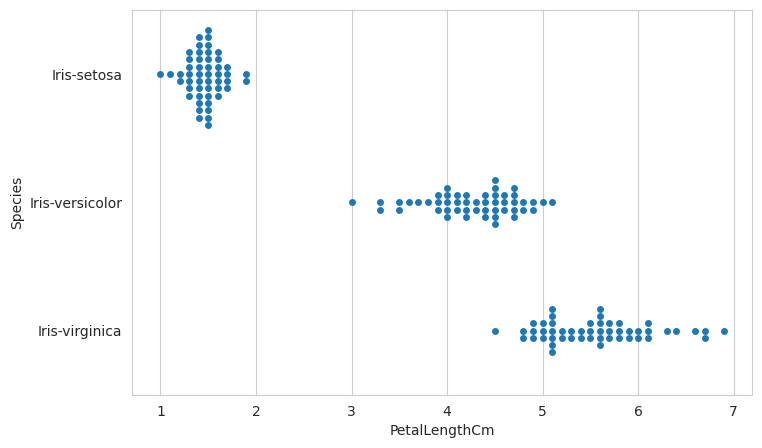

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.swarmplot(data=iris, x='PetalLengthCm',y='Species', ax=ax)

#### De puntos (Cleveland Dot Plot)


- Alternativa a los gráficos de barras
- Lectura más fácil de leer, reducción de "tinta" y facilidad de consulta.

In [46]:
!gdown 1wXT3JQ7F38rjPhpAZL1KhTUJTnBXc8rx
exportaciones_1935_1950 = pd.read_csv('volumen-fisico-exportaciones-precios-constantes-1950-anual.csv')

# Datos
schools = ["Brown", "NYU", "Notre Dame", "Cornell", "Tufts", "Yale",
           "Dartmouth", "Chicago", "Columbia", "Duke", "Georgetown",
           "Princeton", "U.Penn", "Stanford", "MIT", "Harvard"]
n_schools = len(schools)

women_salary = [72, 67, 73, 80, 76, 79, 84, 78, 86, 93, 94, 90, 92, 96, 94, 112]
men_salary = [92, 94, 100, 107, 112, 114, 114, 118, 119, 124, 131, 137, 141, 151, 152, 165]

# Crear DataFrame
df = pd.DataFrame({
    'school': schools * 2,
    'salary': men_salary + women_salary,
    'gender': ['Men'] * n_schools + ['Women'] * n_schools
})

# Asignar una posición a cada escuela en eje Y
school_order = df['school'].unique()
school_pos = {school: i for i, school in enumerate(school_order)}



Downloading...
From: https://drive.google.com/uc?id=1wXT3JQ7F38rjPhpAZL1KhTUJTnBXc8rx
To: /content/volumen-fisico-exportaciones-precios-constantes-1950-anual.csv
100% 2.42k/2.42k [00:00<00:00, 9.12MB/s]


In [48]:
school_order

array(['Brown', 'NYU', 'Notre Dame', 'Cornell', 'Tufts', 'Yale',
       'Dartmouth', 'Chicago', 'Columbia', 'Duke', 'Georgetown',
       'Princeton', 'U.Penn', 'Stanford', 'MIT', 'Harvard'], dtype=object)

In [52]:
school_pos

{'Brown': 0,
 'NYU': 1,
 'Notre Dame': 2,
 'Cornell': 3,
 'Tufts': 4,
 'Yale': 5,
 'Dartmouth': 6,
 'Chicago': 7,
 'Columbia': 8,
 'Duke': 9,
 'Georgetown': 10,
 'Princeton': 11,
 'U.Penn': 12,
 'Stanford': 13,
 'MIT': 14,
 'Harvard': 15}

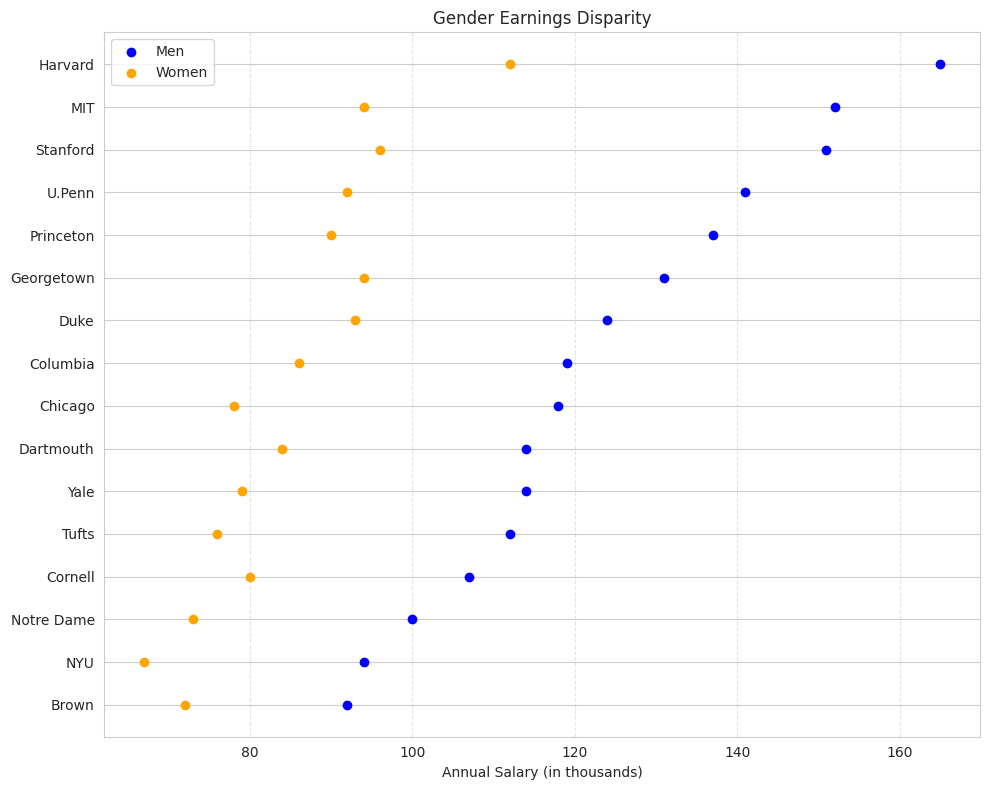

In [51]:
# Crear la figura
plt.figure(figsize=(10, 8))

# Filtrar y graficar por género
for gender, color in zip(['Men', 'Women'], ['blue', 'orange']):
    subset = df[df['gender'] == gender]
    y = [school_pos[school] for school in subset['school']]
    plt.scatter(subset['salary'], y, label=gender, color=color)

# Formato del eje Y con nombres de escuelas
plt.yticks(ticks=range(n_schools), labels=school_order)
plt.xlabel("Annual Salary (in thousands)")
plt.title("Gender Earnings Disparity")
plt.legend()
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [55]:
columnas = ['indice_tiempo', 'vol_fis_expo_prod_agrop_ganad_carnes',
            'vol_fis_expo_prod_agrop_ganad_cueros', 'vol_fis_expo_prod_agrop_ganad_lanas',
            'vol_fis_expo_prod_agrop_ganad_prod_lecheros', 'vol_fis_expo_prod_agrop_ganad_subprod_ganaderos',
            'vol_fis_expo_prod_agrop_ganad_residuos', 'vol_fis_expo_prod_agrop_ganad_total',
            'vol_fis_expo_agric_cereales_lino', 'vol_fis_expo_agric_frutas_frescas_hortalizas_legumbres',
            'vol_fis_expo_agric_otros_prod', 'vol_fis_expo_prod_agric_total',
            'vol_fis_expo_prod_agrop_agric_total', 'vol_fis_expo_prod_forestales',
            'vol_fis_expo_diversos_articulos_manufacturados', 'vol_fis_expo_total']

# Crear el diccionario de mapeo
nuevo_nombres = {
    'vol_fis_expo_prod_agrop_ganad_carnes': 'Carnes',
    'vol_fis_expo_prod_agrop_ganad_cueros': 'Cueros',
    'vol_fis_expo_prod_agrop_ganad_lanas': 'Lanas',
    'vol_fis_expo_prod_agrop_ganad_prod_lecheros': 'Lecheros',
    'vol_fis_expo_prod_agrop_ganad_subprod_ganaderos': 'Subproductos Ganaderos',
    'vol_fis_expo_prod_agrop_ganad_residuos': 'Residuos Ganaderos',
    'vol_fis_expo_prod_agrop_ganad_total': 'Total Ganadero',
    'vol_fis_expo_agric_cereales_lino': 'Cereales Lino',
    'vol_fis_expo_agric_frutas_frescas_hortalizas_legumbres': 'Frutas, Hortalizas y Legumbres',
    'vol_fis_expo_agric_otros_prod': 'Otros Productos Agrícolas',
    'vol_fis_expo_prod_agric_total': 'Total Agrícola',
    'vol_fis_expo_prod_agrop_agric_total': 'Total Agropecuario',
    'vol_fis_expo_prod_forestales': 'Forestales',
    'vol_fis_expo_diversos_articulos_manufacturados': 'Diversos Artículos Manufacturados',
    'vol_fis_expo_total': 'Total General'
}
exportaciones_1935_1950.rename(columns=nuevo_nombres, inplace=True)
exportaciones_1935_1950['indice_tiempo'] = exportaciones_1935_1950['indice_tiempo'].str[:4]

In [57]:
df_guerra = exportaciones_1935_1950[exportaciones_1935_1950['indice_tiempo'].isin(['1939','1940','1941','1942','1943','1944','1945'])]

In [58]:

variables = ['Carnes', 'Cueros', 'Lanas', 'Lecheros','Diversos Artículos Manufacturados']
df_guerra


,indice_tiempo,Carnes,Cueros,Lanas,Lecheros,Subproductos Ganaderos,Residuos Ganaderos,Total Ganadero,Cereales Lino,"Frutas, Hortalizas y Legumbres",Otros Productos Agrícolas,Total Agrícola,Total Agropecuario,Forestales,Diversos Artículos Manufacturados,Total General
4,1939,156.2,71.0,105.0,77.7,73.5,127.1,104.9,199.6,92.9,22.7,154.7,127.7,99.9,182.0,127.5
5,1940,131.4,64.6,100.5,99.3,60.6,105.6,95.9,141.5,61.1,27.0,111.6,103.1,60.1,261.8,104.4
6,1941,187.3,74.4,119.3,147.5,96.3,122.0,123.5,87.8,80.3,41.2,77.4,102.4,68.0,344.2,105.8
7,1942,203.7,41.0,79.4,107.7,144.7,90.1,111.3,64.8,55.8,45.8,60.2,87.9,64.2,600.9,97.3
8,1943,205.0,69.8,77.1,144.6,132.0,88.1,112.3,75.8,48.4,36.6,65.6,90.9,69.7,930.1,107.0
9,1944,234.9,64.8,73.7,158.7,145.4,108.6,119.7,78.1,63.4,49.6,71.0,94.4,58.4,619.4,106.3
10,1945,149.5,57.1,127.9,136.3,141.0,107.7,113.9,77.7,110.5,65.3,77.3,97.2,92.4,546.3,106.1


In [59]:
variables = ['Carnes', 'Cueros', 'Lanas', 'Lecheros',
       'Subproductos Ganaderos', 'Residuos Ganaderos',
       'Cereales Lino', 'Frutas, Hortalizas y Legumbres',
       'Otros Productos Agrícolas',
       'Forestales', 'Diversos Artículos Manufacturados']

### Datos temporales

Con datos tipo timestamp podremos hacer gráficos como:

- De línea: evolución de variable en el tiempo
- Múltiples líneas: para comparar variables
- Moving Average: media móvil en una serie de tiempo
- De área: para graficar acumulado a lo largo del tiempo. Puede stackearse

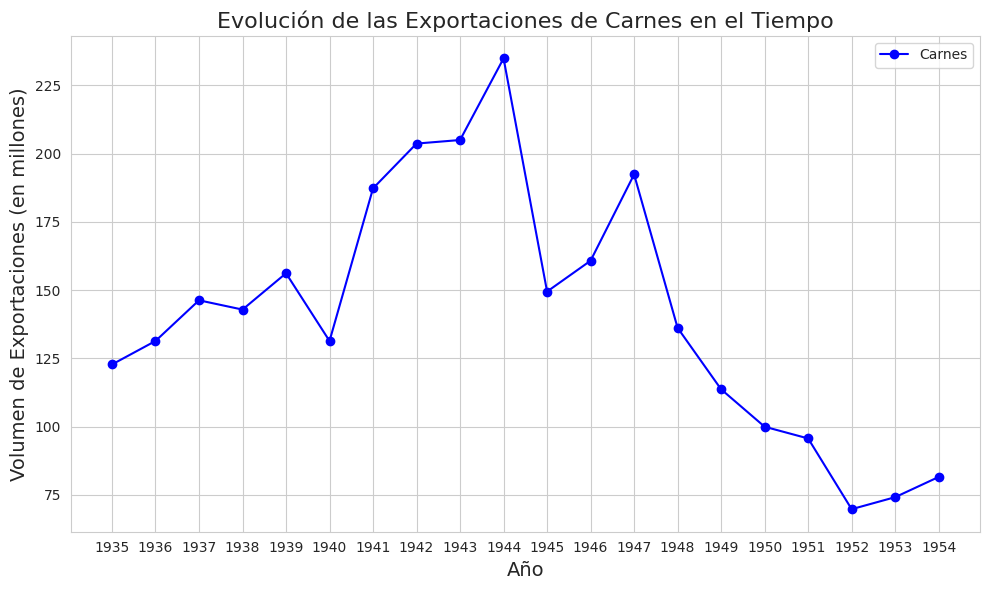

In [60]:
# Crear gráfico de línea para 'Carnes'
plt.figure(figsize=(10, 6))
plt.plot(exportaciones_1935_1950['indice_tiempo'], exportaciones_1935_1950['Carnes'], marker='o', linestyle='-', color='b', label='Carnes')
plt.title('Evolución de las Exportaciones de Carnes en el Tiempo', fontsize=16)
plt.xlabel('Año', fontsize=14)
plt.ylabel('Volumen de Exportaciones (en millones)', fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

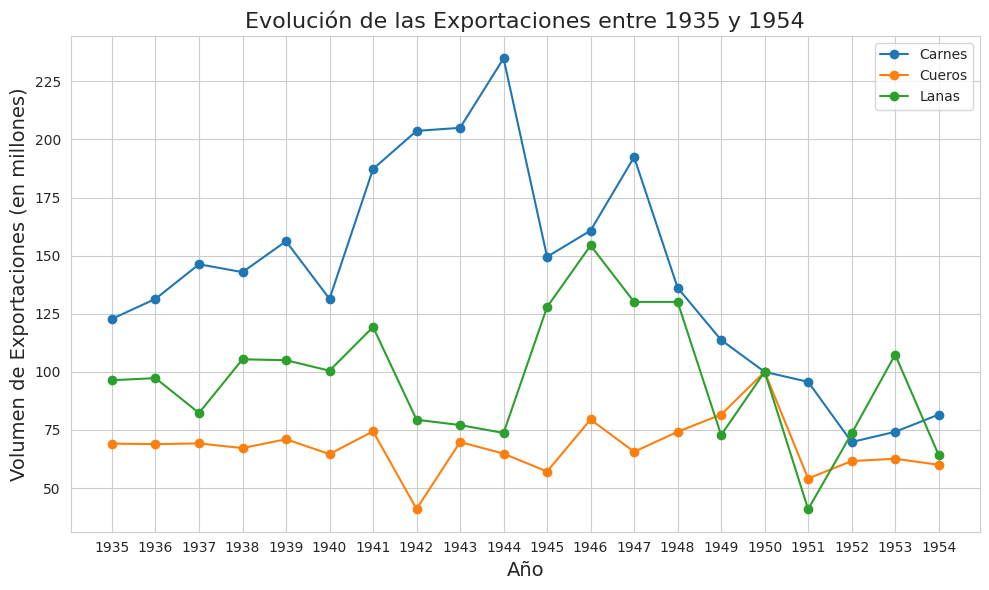

In [61]:

plt.figure(figsize=(10, 6))
plt.plot(exportaciones_1935_1950['indice_tiempo'], exportaciones_1935_1950['Carnes'], marker='o', linestyle='-', label='Carnes')
plt.plot(exportaciones_1935_1950['indice_tiempo'], exportaciones_1935_1950['Cueros'], marker='o', linestyle='-', label='Cueros')
plt.plot(exportaciones_1935_1950['indice_tiempo'], exportaciones_1935_1950['Lanas'], marker='o', linestyle='-', label='Lanas')
plt.title('Evolución de las Exportaciones entre 1935 y 1954', fontsize=16)
plt.xlabel('Año', fontsize=14)
plt.ylabel('Volumen de Exportaciones (en millones)', fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

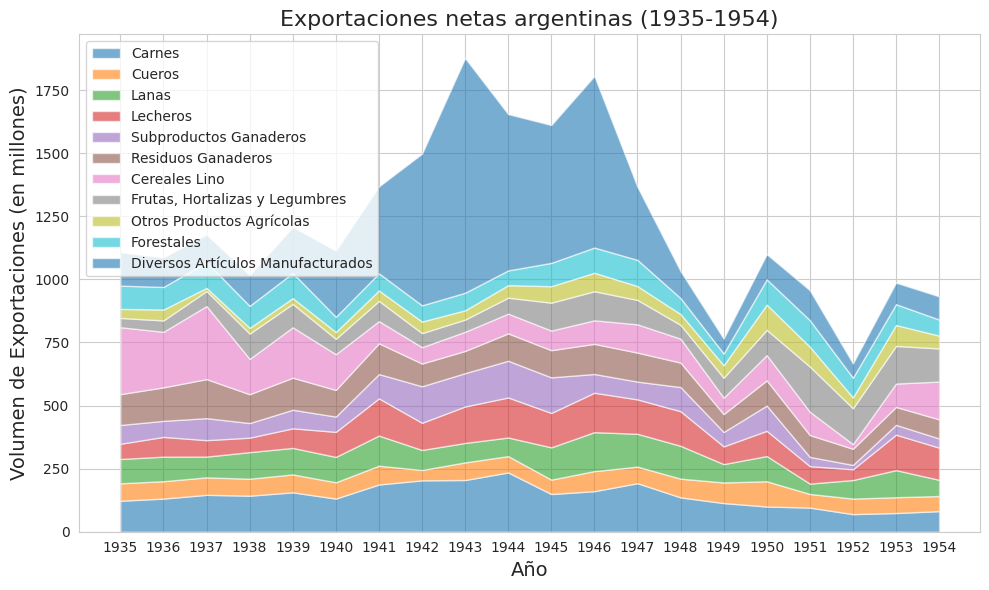

In [62]:
# Graficar área acumulada de varias categorías
plt.figure(figsize=(10, 6))
plt.stackplot(exportaciones_1935_1950['indice_tiempo'], exportaciones_1935_1950[variables].T,
              labels=variables, alpha=0.6)
plt.title('Exportaciones netas argentinas (1935-1954)', fontsize=16)
plt.xlabel('Año', fontsize=14)
plt.ylabel('Volumen de Exportaciones (en millones)', fontsize=14)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


### Datos espaciales

Por datos espaciales se entiende a algo que pueda plotearse contra otra variable (Ej, un gráfico con coordenadas XY).

- Scatter Plot (o de dispersión)
- Scatter Plot (con variantes)
- Heatmap


#### Gráfico de dispersión *(scatter plot)*

In [65]:
!gdown 10Wfu22uGTNPt9PRV2jTTr4zsJ4W_PWlU
df_IMC = pd.read_excel('IMCinfantil.xlsx', index_col=0)

Downloading...
From: https://drive.google.com/uc?id=10Wfu22uGTNPt9PRV2jTTr4zsJ4W_PWlU
To: /content/IMCinfantil.xlsx
100% 21.5k/21.5k [00:00<00:00, 54.6MB/s]


In [66]:
df_IMC

,EDAD,SEXO,PESO,TALLA,IMC,PIMC,CC,CatPeso
PACIENTE,,,,,,,,
1,7,M,24.4,1.2,16.944444,7.97,54,N
2,7,M,23.6,1.2,16.388889,72.72,52,N
3,8,M,47.0,1.4,23.979592,97.08,76,OB
4,7,F,24.0,1.2,16.666667,83.88,63,N
5,7,M,23.9,1.2,16.597222,45.85,56,N
...,...,...,...,...,...,...,...,...
146,11,M,52.9,1.5,23.511111,93.45,84,SO
147,8,M,26.5,1.2,18.402778,79.69,57,N
148,6,F,21.5,1.1,17.768595,72.12,57,N


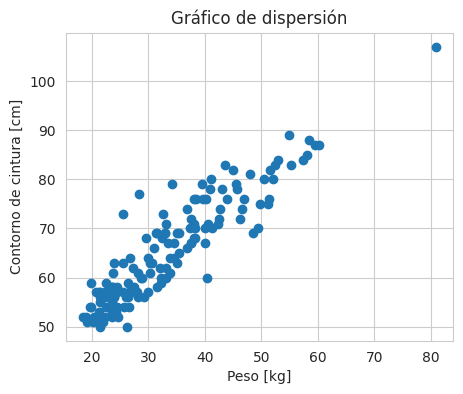

In [67]:
fig = plt.figure(figsize=(5,4))
ax = fig.subplots()
ax.scatter('PESO','CC',data = df_IMC)
ax.set_title('Gráfico de dispersión')
ax.set_ylabel('Contorno de cintura [cm]')
ax.set_xlabel('Peso [kg]')
ax.grid(True, axis='y')
ax.set_axisbelow(True)

In [68]:
df_IMC['SEXO'].unique()

array(['M', 'F'], dtype=object)

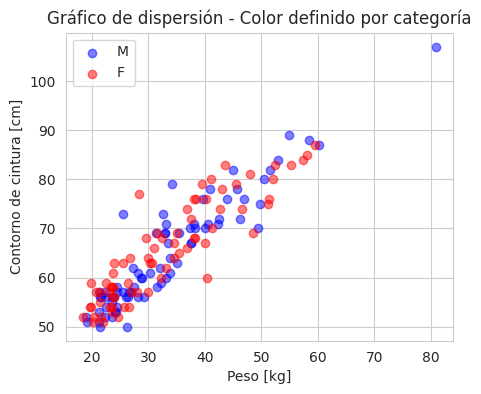

In [69]:
fig = plt.figure(figsize=(5,4))
ax = fig.subplots()

colores = {'F': 'red', 'M': 'blue'}

for cat in df_IMC['SEXO'].unique():
    df_categoria = df_IMC[df_IMC['SEXO'] == cat]
    ax.scatter(x = df_categoria['PESO'],
               y = df_categoria['CC'],
               c = colores[cat], alpha = 0.5,
               label = cat)

ax.set_title('Gráfico de dispersión - Color definido por categoría')
ax.set_ylabel('Contorno de cintura [cm]')
ax.set_xlabel('Peso [kg]')
ax.grid(True)
ax.set_axisbelow(True)
ax.legend()

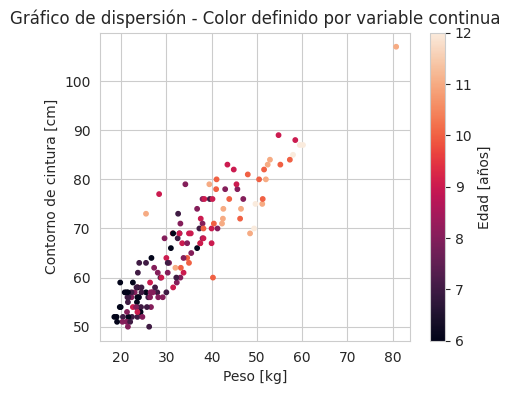

In [70]:
fig = plt.figure(figsize=(5,4))
ax = fig.subplots()

plot = ax.scatter('PESO','CC',data = df_IMC, c=df_IMC['EDAD'], s=10)

ax.set_title('Gráfico de dispersión - Color definido por variable continua')
ax.set_ylabel('Contorno de cintura [cm]')
ax.set_xlabel('Peso [kg]')
ax.grid(True)
ax.set_axisbelow(True)

plt.colorbar(plot, label = 'Edad [años]')

Notas:
*	Elegir el tamaño correcto de marcadores
*	Usar colores para añadir una dimensión.
*	Si hay datos solapándose (común cuando una de las variables es discreta) aplicar transparencia.
*	Si se quiere agregar otra dimensión (variable) más, usar *bubble plots* (ejemplo más adelante).

## Seaborn - visualizaciones útiles

### Boxplots comparativos

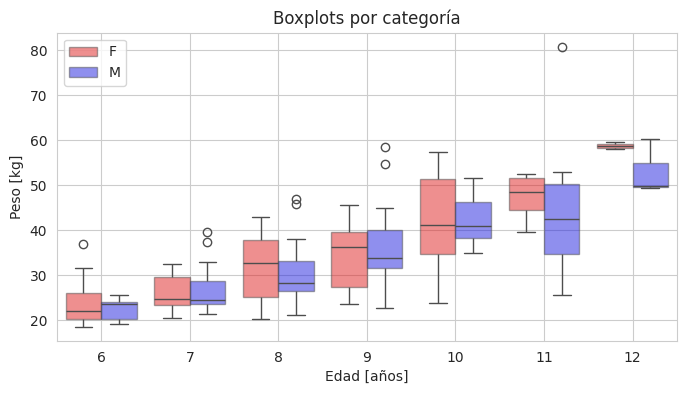

In [71]:
import seaborn as sns
fig = plt.figure(figsize=(8,4))
ax = fig.subplots()

ax = sns.boxplot(data=df_IMC, x="EDAD", y="PESO", hue="SEXO", palette=colores, boxprops=dict(alpha=.5))

ax.set_title('Boxplots por categoría')
ax.set_ylabel('Peso [kg]')
ax.set_xlabel('Edad [años]')
ax.grid(True)
ax.set_axisbelow(True)
ax.legend(loc='upper left')

### Pairplot

In [73]:
# Descarga del dataset

!gdown 16lJns3YvvVg_YmEVYMj1l9oRq5YU5YN-

# Carga del dataset

df_vinos = pd.read_csv('winequality.csv')
df_vinos = df_vinos.rename(columns={"type": "tipo",
                                    "fixed acidity": "acidez fija",
                                    "volatile acidity": "acidez volátil",
                                    "citric acid": "ácido cítrico",
                                    "residual sugar" : "azúcar residual",
                                    "chlorides" : "cloruros",
                                    "free sulfur dioxide" : "dióxido de azufre libre",
                                    "total sulfur dioxide" : "dióxido de azufre total",
                                    "density" : "densidad",
                                    "sulphates" : "sulfatos",
                                    "alcohol" : "alcohol",
                                    "quality" : "calidad"})

df_vinos['tipo'] = df_vinos['tipo'].map({'white':'blanco',
                                         'red':'tinto'})

Downloading...
From: https://drive.google.com/uc?id=16lJns3YvvVg_YmEVYMj1l9oRq5YU5YN-
To: /content/winequality.csv
100% 390k/390k [00:00<00:00, 6.60MB/s]


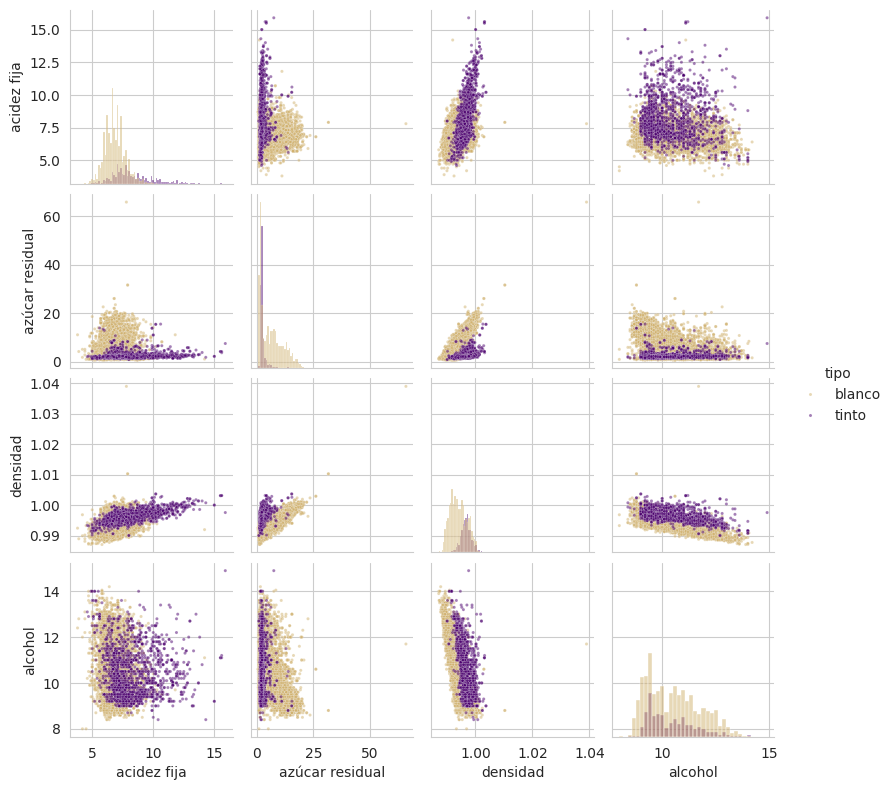

In [74]:
variables_seleccionadas = ['tipo', 'acidez fija', 'azúcar residual', 'densidad', 'alcohol']

fig = sns.pairplot(data=df_vinos[variables_seleccionadas],
                   hue="tipo",
                   palette={'tinto':'#4b006e', 'blanco':'#d1b26f'},
                   diag_kind="hist",
                   plot_kws={'alpha':0.5,
                             's': 5},
                   height=2)

### Bubble plot
Permite visualizar 4 variables en un sólo gráfico.


/tmp/ipython-input-1055653655.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['pop_million_hab'] = data['pop'] / 1000000


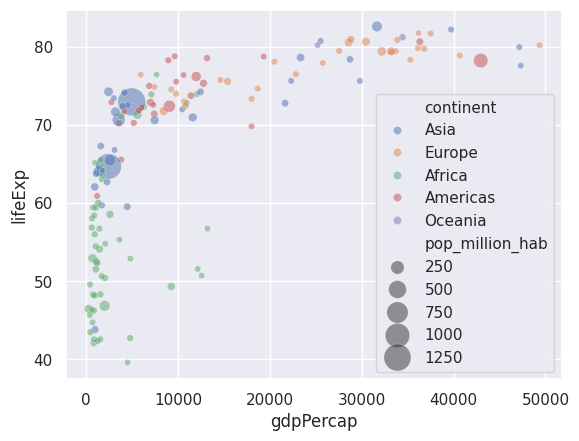

In [75]:
gapminder = pd.read_csv(
    'https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/gapminderData.csv'
)
data = gapminder.loc[gapminder.year == 2007]
data['pop_million_hab'] = data['pop'] / 1000000

sns.set_theme(style="darkgrid")

# use the scatterplot function
sns.scatterplot(
    data=data,
    x="gdpPercap",
    y="lifeExp",
    size="pop_million_hab",
    hue="continent",
    alpha=0.5,
    sizes=(20, 400)
)

# show the graph
plt.show();

## Otro tipo de visualización de datos: Tablas
Algunas consideraciones:
-	Ordenar filas de acuerdo a categorías o variables importantes.
-	Ordenar columnas de acuerdo a la importancia (menos importante a la derecha). Mostrar juntas las columnas que estén relacionadas o se busque comparar.
-	Presentar valores numéricos con la misma precisión y justificados hacia la derecha.
-	Destacar valores importantes con el formato de **texto**.
-	Evitar encabezados de columnas muy largos. Abreviar y aclarar en la descripción, o usar encabezados de más de una línea.
- No son necesarias las líneas divisorias entre filas, ni los bordes externos de la tabla.



EJEMPLO (Fuente: Skiena, 2017)

**Tabla inicial:**

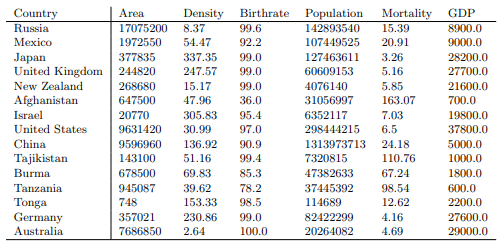

**Tabla mejorada**:

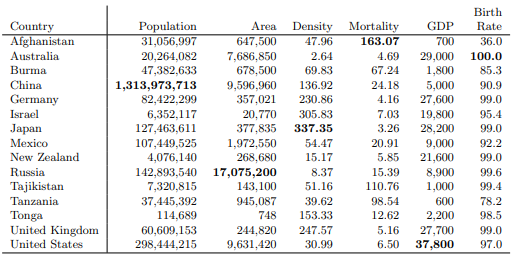

### Latex en Python

> LaTeX es un sistema de composición de textos orientado a la creación de documentos escritos que presenten una alta calidad tipográfica. Por sus características y posibilidades, se usa de forma especialmente intensa en la generación de artículos y libros científicos que incluyen, entre otros elementos, expresiones matemáticas.



In [77]:

# Exportamos a LaTeX
latex_exportaciones = exportaciones_1935_1950.to_latex(index=False,float_format="{:.1f}".format)



In [78]:
exportaciones_1935_1950

,indice_tiempo,Carnes,Cueros,Lanas,Lecheros,Subproductos Ganaderos,Residuos Ganaderos,Total Ganadero,Cereales Lino,"Frutas, Hortalizas y Legumbres",Otros Productos Agrícolas,Total Agrícola,Total Agropecuario,Forestales,Diversos Artículos Manufacturados,Total General
0,1935,122.8,69.1,96.4,60.4,74.4,122.2,92.5,265.2,36.7,35.8,200.7,142.0,92.3,131.9,139.6
1,1936,131.4,68.9,97.3,78.2,63.6,132.8,95.7,220.0,45.2,43.2,170.4,129.9,89.4,117.3,127.8
2,1937,146.3,69.2,82.3,65.2,87.1,154.8,95.1,289.4,59.7,12.2,214.7,149.9,102.1,109.5,146.9
3,1938,142.9,67.2,105.4,57.3,57.9,114.3,98.4,140.0,100.5,22.4,112.3,104.7,87.3,121.7,104.3
4,1939,156.2,71.0,105.0,77.7,73.5,127.1,104.9,199.6,92.9,22.7,154.7,127.7,99.9,182.0,127.5
5,1940,131.4,64.6,100.5,99.3,60.6,105.6,95.9,141.5,61.1,27.0,111.6,103.1,60.1,261.8,104.4
6,1941,187.3,74.4,119.3,147.5,96.3,122.0,123.5,87.8,80.3,41.2,77.4,102.4,68.0,344.2,105.8
7,1942,203.7,41.0,79.4,107.7,144.7,90.1,111.3,64.8,55.8,45.8,60.2,87.9,64.2,600.9,97.3
8,1943,205.0,69.8,77.1,144.6,132.0,88.1,112.3,75.8,48.4,36.6,65.6,90.9,69.7,930.1,107.0
9,1944,234.9,64.8,73.7,158.7,145.4,108.6,119.7,78.1,63.4,49.6,71.0,94.4,58.4,619.4,106.3


In [79]:
from tabulate import tabulate

exportaciones_latex2 = tabulate(exportaciones_1935_1950, headers='keys', tablefmt='latex', showindex=False)
exportaciones_latex2


'\\begin{tabular}{rrrrrrrrrrrrrrrr}\n\\hline\n   indice\\_tiempo &   Carnes &   Cueros &   Lanas &   Lecheros &   Subproductos Ganaderos &   Residuos Ganaderos &   Total Ganadero &   Cereales Lino &   Frutas, Hortalizas y Legumbres &   Otros Productos Agrícolas &   Total Agrícola &   Total Agropecuario &   Forestales &   Diversos Artículos Manufacturados &   Total General \\\\\n\\hline\n            1935 &    122.8 &     69.1 &    96.4 &       60.4 &                     74.4 &                122.2 &             92.5 &           265.2 &                             36.7 &                        35.8 &            200.7 &                142   &         92.3 &                               131.9 &           139.6 \\\\\n            1936 &    131.4 &     68.9 &    97.3 &       78.2 &                     63.6 &                132.8 &             95.7 &           220   &                             45.2 &                        43.2 &            170.4 &                129.9 &         89.4 &     

In [80]:
exportaciones_latex2

'\\begin{tabular}{rrrrrrrrrrrrrrrr}\n\\hline\n   indice\\_tiempo &   Carnes &   Cueros &   Lanas &   Lecheros &   Subproductos Ganaderos &   Residuos Ganaderos &   Total Ganadero &   Cereales Lino &   Frutas, Hortalizas y Legumbres &   Otros Productos Agrícolas &   Total Agrícola &   Total Agropecuario &   Forestales &   Diversos Artículos Manufacturados &   Total General \\\\\n\\hline\n            1935 &    122.8 &     69.1 &    96.4 &       60.4 &                     74.4 &                122.2 &             92.5 &           265.2 &                             36.7 &                        35.8 &            200.7 &                142   &         92.3 &                               131.9 &           139.6 \\\\\n            1936 &    131.4 &     68.9 &    97.3 &       78.2 &                     63.6 &                132.8 &             95.7 &           220   &                             45.2 &                        43.2 &            170.4 &                129.9 &         89.4 &     

## Bibliografía

Cheat Sheets


> [Pandas Cheat Sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf)

> [NumPy Cheat Sheets](https://speedsheet.io/s/numpy)

Documentación de módulos

> [NumPy](https://numpy.org/doc/1.26/)

> [Pandas](https://pandas.pydata.org/docs/)

> [Seaborn](https://seaborn.pydata.org/)

Recursos útiles:

> [Python graph gallery](https://python-graph-gallery.com/)

> [Data viz catalogue](https://datavizcatalogue.com/)

> [Flourish](https://app.flourish.studio/projects)

Teoría visualización

> • Skiena, S. S. (2017). The data science design manual. Springer.

> • Healy, K. (2018). Data visualization: a practical introduction. Princeton University Press.

> • Tufte Edward R. - The Visual Display of Quantitative Information (2ed)
